# Woche 7: Data Cleaning - Übung am eigenen Projekt

**Ziel dieser Übung:** Nachdem Sie die wichtigsten Aspekte des Data Cleanings am Airbnb-Beispiel kennengelernt haben, wenden Sie dieses Wissen Schritt für Schritt auf Ihren eigenen Datensatz an.

**Arbeitsweise:**
- Arbeiten Sie die Aufgaben nacheinander durch
- Nutzen Sie die Code-Zellen für Ihre Implementierung
- Orientieren Sie sich an den Beispielen aus dem Airbnb-Notebook
- Das bereinigte Dataset speichern Sie am Ende ab

---
## 1. Daten einlesen und Bibliotheken importieren

**Aufgabe:** Importieren Sie die notwendigen Bibliotheken und laden Sie Ihren Datensatz.

**Hinweise:**
- Importieren Sie: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- Setzen Sie einen Zufallsseed für Reproduzierbarkeit
- Laden Sie Ihren CSV-Datensatz mit `pd.read_csv()`

In [2]:
# Bibliotheken importieren
import pathlib as pl
import os
import PIL
import matplotlib.pyplot as plt
import seaborn
import pandas as pd
import numpy as np

# Zufallsseed setzen

np.random.seed(42)


# Datensatz einlesen
# df = pd.read_csv('ihr_datensatz.csv')


df_meta = pd.read_csv('metadata.csv')
df_meta_clean = df_meta.copy()






---
## 2. Ersten Überblick verschaffen

**Aufgabe:** Verschaffen Sie sich einen ersten Überblick über Ihren Datensatz.

**Was Sie prüfen sollten:**
- Wie viele Zeilen und Spalten hat der Datensatz?
- Welche Spalten gibt es und welche Datentypen haben sie?
- Wie sehen die ersten Zeilen aus?

In [3]:
# Dimensionen des Datensatzes

print(f"Geladen: {df_meta.shape[0]} Zeilen, {df_meta.shape[1]} Spalten")

# Erste Zeilen anzeigen

print(df_meta.head())

# Informationen zu Spalten und Datentypen

print()

print("Spalten:\n")

print(df_meta.columns)

print()

print("Datatypes:\n")

print(df_meta.dtypes)


Geladen: 10000 Zeilen, 9 Spalten
    image_filename  split          drone_types  num_drones condition  \
0  drone_00000.jpg  train  mohajer_6;mohajer_6           2      hazy   
1  drone_00001.jpg  train            mohajer_6           1     night   
2  drone_00002.jpg   test           shahed_136           1     night   
3  drone_00003.jpg  train           shahed_238           1       day   
4  drone_00004.jpg  train           mq9_reaper           1     night   

   avg_drone_size_pct  has_occlusion  has_motion_blur background_source  
0              0.0017          False            False     hazy_0030.jpg  
1              0.0025          False             True    night_0017.jpg  
2              0.0079           True            False    night_0073.jpg  
3              0.0045          False             True      day_0005.jpg  
4              0.0020          False             True    night_0060.jpg  

Spalten:

Index(['image_filename', 'split', 'drone_types', 'num_drones', 'condition',
   

['.DS_Store', 'test', 'train', 'val']


Text(0.5, 1.0, 'train')

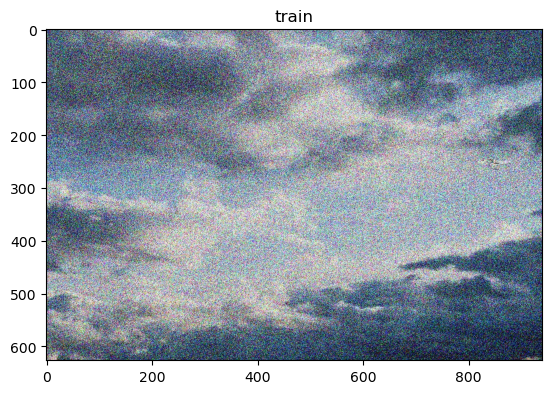

In [4]:
#Pfadanschauen

print(os.listdir('./images'))

#Nehme das erste Bild

sample = df_meta.iloc[0]

#suche den Pfad dieses Bilds

bild_pfad = os.path.join(('images'), sample['split'], sample['image_filename'])

#zeige das Bild

img = PIL.Image.open(bild_pfad)

plt.imshow(img)

plt.title(sample['split'])

---
## 3. Fehlende Werte identifizieren

**Aufgabe:** Untersuchen Sie Ihren Datensatz auf fehlende Werte.

**Was Sie tun sollten:**
- Zählen Sie fehlende Werte pro Spalte
- Berechnen Sie den Prozentsatz fehlender Werte
- Visualisieren Sie fehlende Werte (optional: Heatmap)

In [5]:
# Fehlende Werte zählen

missing = df_meta_clean.isnull().sum()

# Prozentsatz fehlender Werte berechnen

missing_percentage = (missing/len(df_meta_clean))*100

# Optional: Visualisierung mit Heatmap

missing_df = pd.DataFrame({
    'spalte': missing.index,
    'fehlend': missing.values,
    'prozent': missing_percentage.values
    
})

print(missing_df)

#Prüfen ob für jeweilige split Kategorie gleiche Anzahl wie Bilder im split ordner?

print(df_meta['split'].value_counts())

meta_train_value = (df_meta['split'] == 'train').sum()

meta_test_value = (df_meta['split'] == 'test').sum()

meta_val_value = (df_meta['split'] == 'val').sum()


print(meta_train_value+meta_test_value+meta_val_value)

train_pfad = os.path.join(('images'), 'train')
test_pfad = os.path.join(('images'), 'test')
val_pfad = os.path.join(('images'), 'val')

train_anzahl_bilder = len(os.listdir(train_pfad))
test_anzahl_bilder = len(os.listdir(test_pfad))
val_anzahl_bilder = len(os.listdir(val_pfad))

print()

print("Anzahl der Train Values im Meta csv:\n")

print(meta_train_value)

print()

print("Anzahl der Test Values im Meta csv:\n")

print(meta_test_value)

print()

print("Anzahl der Val Values im Meta csv:\n")

print(meta_val_value)

print()

print("Bildanzahl und Einträge matchen: \n")

print(train_anzahl_bilder == meta_train_value and val_anzahl_bilder == meta_val_value and test_anzahl_bilder == meta_test_value)

               spalte  fehlend  prozent
0      image_filename        0      0.0
1               split        0      0.0
2         drone_types        0      0.0
3          num_drones        0      0.0
4           condition        0      0.0
5  avg_drone_size_pct        0      0.0
6       has_occlusion        0      0.0
7     has_motion_blur        0      0.0
8   background_source        0      0.0
split
train    7003
val      2001
test      996
Name: count, dtype: int64
10000

Anzahl der Train Values im Meta csv:

7003

Anzahl der Test Values im Meta csv:

996

Anzahl der Val Values im Meta csv:

2001

Bildanzahl und Einträge matchen: 

False


---
## 4. Fehlende Werte behandeln

**Aufgabe:** Entscheiden Sie für jede Spalte mit fehlenden Werten, wie Sie damit umgehen.

**Mögliche Strategien:**
- Zeilen löschen (bei wenigen fehlenden Werten)
- Spalten löschen (bei sehr vielen fehlenden Werten)
- Fehlende Werte imputieren:
  - Numerische Spalten: Median oder Mittelwert
  - Kategoriale Spalten: Modus oder neue Kategorie

**Dokumentieren Sie Ihre Entscheidungen!**

In [6]:
# Strategie 1: Zeilen mit fehlenden Werten löschen (falls anwendbar)
# df = df.dropna(subset=['spaltenname'])


#fehlerhafte Werte finden

print(df_meta_clean['avg_drone_size_pct'].describe())

# Strategie 2: Spalten mit zu vielen fehlenden Werten löschen
# df = df.drop(columns=['spaltenname'])


# Strategie 3: Numerische Werte imputieren
# df['spaltenname'] = df['spaltenname'].fillna(df['spaltenname'].median())



# Strategie 4: Kategoriale Werte imputieren
# df['spaltenname'] = df['spaltenname'].fillna('Unknown')


# Neue Kategorien hinhzufügen bzw. mappen:

#print(df_meta_clean.columns)

#print(df_meta_clean['drone_types'].unique())

combat_drones = ['mq9_reaper', 'shahed_136', 'shahed_238', 'mohajer_6']



def categorize_drones(drone_string):

    if pd.isna(drone_string):
        return pd.NA
    
    drone_in_images = drone_string.split(';')

    for drone in drone_in_images:
        if drone in combat_drones:
            return True

    return False
        


df_meta_clean['is_combat_drone'] = df_meta_clean['drone_types'].apply(categorize_drones)


drone_columns = ['mq9_reaper', 'shahed_136', 'shahed_238', 'mohajer_6', 'dji_mavic']

df_meta_clean[drone_columns] = 0


def split_drones(zeile):


    
    
    if pd.isna(zeile['drone_types']):
        return zeile


    Dronen = zeile['drone_types'].split(';')

    
    for drone in Dronen:
        if drone == 'mq9_reaper':
            zeile['mq9_reaper'] += 1

        if drone == 'shahed_136':
            zeile['shahed_136'] += 1
            
        if drone == 'shahed_238':
            zeile['shahed_238'] += 1
            
        if drone == 'mohajer_6':
            zeile['mohajer_6'] += 1
            
        if drone == 'dji_mavic':
            zeile['dji_mavic'] += 1


    return zeile
        
df_meta_clean = df_meta_clean.apply(split_drones, axis=1)


#Überprüfen

df_meta_clean[:15]









count    10000.000000
mean         0.001948
std          0.001664
min          0.000100
25%          0.000700
50%          0.001600
75%          0.002700
max          0.029000
Name: avg_drone_size_pct, dtype: float64


,image_filename,split,drone_types,num_drones,condition,avg_drone_size_pct,has_occlusion,has_motion_blur,background_source,is_combat_drone,mq9_reaper,shahed_136,shahed_238,mohajer_6,dji_mavic
0,drone_00000.jpg,train,mohajer_6;mohajer_6,2,hazy,0.0017,False,False,hazy_0030.jpg,True,0,0,0,2,0
1,drone_00001.jpg,train,mohajer_6,1,night,0.0025,False,True,night_0017.jpg,True,0,0,0,1,0
2,drone_00002.jpg,test,shahed_136,1,night,0.0079,True,False,night_0073.jpg,True,0,1,0,0,0
3,drone_00003.jpg,train,shahed_238,1,day,0.0045,False,True,day_0005.jpg,True,0,0,1,0,0
4,drone_00004.jpg,train,mq9_reaper,1,night,0.0020,False,True,night_0060.jpg,True,1,0,0,0,0
5,drone_00005.jpg,train,mohajer_6;shahed_238,2,day,0.0006,True,False,day_0023.jpg,True,0,0,1,1,0
6,drone_00006.jpg,train,mohajer_6,1,hazy,0.0016,False,True,hazy_0082.jpg,True,0,0,0,1,0
7,drone_00007.jpg,train,shahed_238;mohajer_6;dji_mavic,3,hazy,0.0027,False,True,hazy_0088.jpg,True,0,0,1,1,1
8,drone_00008.jpg,val,shahed_136;shahed_136,2,hazy,0.0008,False,True,hazy_0036.jpg,True,0,2,0,0,0
9,drone_00009.jpg,train,dji_mavic,1,day,0.0036,False,False,day_0036.jpg,False,0,0,0,0,1


In [6]:
# Überprüfung: Sind alle fehlenden Werte behandelt?


---
## 5. Duplikate identifizieren und entfernen

**Aufgabe:** Prüfen Sie, ob Ihr Datensatz doppelte Zeilen enthält.

**Was Sie tun sollten:**
- Zählen Sie die Anzahl doppelter Zeilen
- Entfernen Sie Duplikate (falls vorhanden)
- Überprüfen Sie die neue Anzahl der Zeilen

In [7]:
# Anzahl doppelter Zeilen

dups = df_meta_clean.duplicated(subset=['image_filename']).sum()

print(dups)

# Duplikate entfernen

df_meta_clean.drop_duplicates(subset=['image_filename'],inplace=True)

print(f"Nach Entfernung: {df_meta_clean.shape[0]} Zeilen")

# Neue Dimensionen prüfen

print(df_meta_clean.shape)




0
Nach Entfernung: 10000 Zeilen
(10000, 15)


---
## 6. Datentypen überprüfen und anpassen

**Aufgabe:** Stellen Sie sicher, dass alle Spalten die richtigen Datentypen haben.

**Was Sie prüfen sollten:**
- Sind numerische Spalten als `int` oder `float` kodiert?
- Sind kategoriale Spalten als `object` oder `category` kodiert?
- Müssen Datentypen konvertiert werden?

In [8]:
# Datentypen anzeigen

print(df_meta_clean.dtypes)

#vlt background_source  löschen brauche ich die??

# Datentypen konvertieren (falls nötig)

print(df_meta_clean.info())

# df['spaltenname'] = df['spaltenname'].astype('int')


df_meta_clean['is_combat_drone'] = df_meta_clean['is_combat_drone'].astype('bool')

# df['spaltenname'] = df['spaltenname'].astype('category')

print("New Datatypes:\n")

print(df_meta_clean.dtypes)

print(df_meta_clean[::15])




image_filename         object
split                  object
drone_types            object
num_drones              int64
condition              object
avg_drone_size_pct    float64
has_occlusion            bool
has_motion_blur          bool
background_source      object
is_combat_drone          bool
mq9_reaper              int64
shahed_136              int64
shahed_238              int64
mohajer_6               int64
dji_mavic               int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   image_filename      10000 non-null  object 
 1   split               10000 non-null  object 
 2   drone_types         10000 non-null  object 
 3   num_drones          10000 non-null  int64  
 4   condition           10000 non-null  object 
 5   avg_drone_size_pct  10000 non-null  float64
 6   has_occlusion       10000 non-n

---
## 7. Ausreißer identifizieren

**Aufgabe:** Identifizieren Sie Ausreißer in numerischen Spalten.

**Methoden:**
- Visualisierung mit Boxplots
- IQR-Methode (Interquartile Range)
- Statistische Analyse (describe)

**Wichtig:** Entscheiden Sie für jeden Ausreißer, ob er:
- Ein Fehler ist (→ entfernen oder korrigieren)
- Ein echter extremer Wert ist (→ behalten)

         num_drones  avg_drone_size_pct    mq9_reaper    shahed_136  \
count  10000.000000        10000.000000  10000.000000  10000.000000   
mean       1.496600            0.001948      0.303900      0.296200   
std        0.669801            0.001664      0.510069      0.503081   
min        1.000000            0.000100      0.000000      0.000000   
25%        1.000000            0.000700      0.000000      0.000000   
50%        1.000000            0.001600      0.000000      0.000000   
75%        2.000000            0.002700      1.000000      1.000000   
max        3.000000            0.029000      3.000000      3.000000   

         shahed_238     mohajer_6     dji_mavic  
count  10000.000000  10000.000000  10000.000000  
mean       0.299500      0.301600      0.295400  
std        0.505594      0.508393      0.502558  
min        0.000000      0.000000      0.000000  
25%        0.000000      0.000000      0.000000  
50%        0.000000      0.000000      0.000000  
75%       

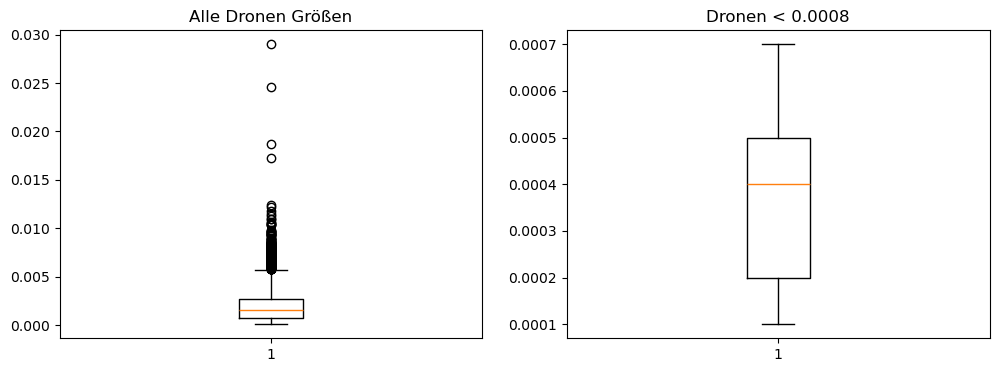

Text(0.5, 1.0, 'Alle Anzahlen an Dronen pro Bild')

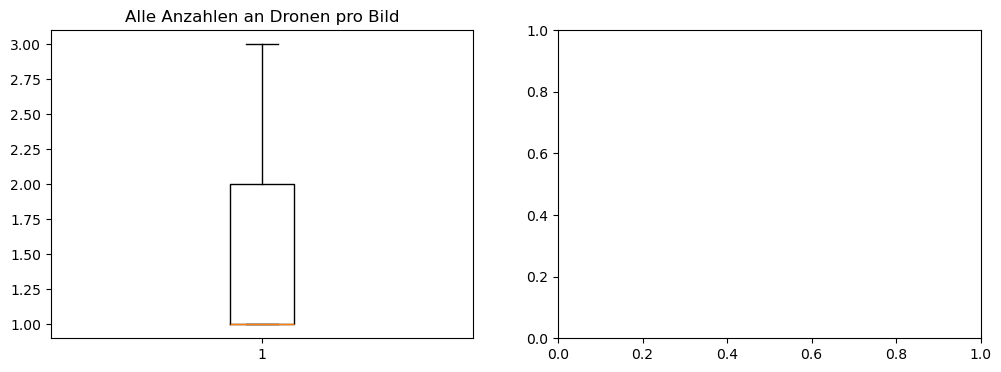

In [9]:
# Numerische Spalten auswählen

print(df_meta_clean.describe())

# numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("DroneSize-Statistiken:")
print(df_meta_clean['avg_drone_size_pct'].describe())


# Statistische Übersicht


# Boxplots für numerische Spalten erstellen (avg_drone_size_pct)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_meta_clean['avg_drone_size_pct'].dropna())
axes[0].set_title('Alle Dronen Größen')

filtered = df_meta_clean[df_meta_clean['avg_drone_size_pct'] < 0.0008]
axes[1].boxplot(filtered['avg_drone_size_pct'].dropna())
axes[1].set_title('Dronen < 0.0008')
plt.show()



#Boxplots für num_drones

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].boxplot(df_meta_clean['num_drones'].dropna())
axes[0].set_title('Alle Anzahlen an Dronen pro Bild')



#filtered = df_meta_clean[df_meta_clean['num_drones']]



In [10]:
# Ausreißer mit IQR-Methode identifizieren (Beispiel für eine Spalte)
# Q1 = df['spaltenname'].quantile(0.25)
# Q3 = df['spaltenname'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# outliers = df[(df['spaltenname'] < lower_bound) | (df['spaltenname'] > upper_bound)]

Q1 = df_meta_clean['avg_drone_size_pct'].quantile(0.25)
Q3 = df_meta_clean['avg_drone_size_pct'].quantile(0.75)

#print(Q1)
#print(Q3)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_meta_clean[(df_meta_clean['avg_drone_size_pct'] < lower_bound) 
    | (df_meta_clean['avg_drone_size_pct'] > upper_bound)]


print(outliers.count())



image_filename        304
split                 304
drone_types           304
num_drones            304
condition             304
avg_drone_size_pct    304
has_occlusion         304
has_motion_blur       304
background_source     304
is_combat_drone       304
mq9_reaper            304
shahed_136            304
shahed_238            304
mohajer_6             304
dji_mavic             304
dtype: int64


---
## 8. Ausreißer behandeln

**Aufgabe:** Behandeln Sie die identifizierten Ausreißer entsprechend Ihrer Analyse.

**Mögliche Strategien:**
- Ausreißer entfernen (wenn sie Fehler sind)
- Ausreißer behalten (wenn sie valide sind)
- Ausreißer begrenzen (Capping/Flooring)

**Dokumentieren Sie Ihre Entscheidungen!**

In [11]:
# Beispiel: Ausreißer entfernen 

# Schwanke hierzwischen und Aureißer behalten (siehe unten), 
#Capping an sich gut denke ich, aber falls ich doch 
#irgednwann die Yolo-Labels brauche wären die ja verfälscht?


#df = df[(df['abg_drone_size_pct'] <= upper_bound)]

ausreisser = df_meta_clean[df_meta_clean['avg_drone_size_pct'] > upper_bound]

gelöschte_txt = 0

gelöschte_bilder = 0

for index, row in ausreisser.iterrows():

    bild_name = row['image_filename']

    bild_id = os.path.splitext(bild_name)[0]
    
    txt_name = f"drone_{bild_id}.txt"

    directory_txt = os.path.join(('labels'), (row['split']), (txt_name))

    directory_bild = os.path.join(('images'), (row['split']), (bild_name))


                                  
    if os.path.exists(directory_txt):                                      
        os.remove(directory_txt)
        gelöschte_txt+=1

    if os.path.exists(directory_bild):
        os.remove(directory_bild)
        gelöschte_bilder+=1



# Beispiel: Capping anwenden
# df['spaltenname'] = df['spaltenname'].clip(lower=lower_bound, upper=upper_bound)

df_meta_clean = df_meta_clean[df_meta_clean['avg_drone_size_pct'] <= upper_bound]

#Ich habe die Aureißer behalten, da wenn ich Fotos im Training habe 
#bei den die Drone sehr nah an der Kamera ist diese ansonsten nicht erkannt wird (hohe drone_size)

len(df_meta_clean)

9696

---
## 9. Inkonsistenzen beheben

**Aufgabe:** Suchen Sie nach Inkonsistenzen in kategorialen Spalten.

**Was Sie prüfen sollten:**
- Unterschiedliche Schreibweisen (z.B. "ja", "Ja", "JA")
- Leerzeichen am Anfang oder Ende
- Tippfehler
- Unerwartete Kategorien

In [12]:
# Kategoriale Spalten auswählen

categorical_cols = df_meta_clean.select_dtypes(include=['object', 'category']).columns

categorical_cols


for col in categorical_cols:
    
    print(f"{col}: {df_meta_clean[col].nunique()}")
    
#print(df_meta_clean['split'].unique())


# Einzigartige Werte pro kategorialer Spalte anzeigen
# for col in categorical_cols:
#     print(f"\n{col}:")
#     print(df[col].value_counts())


image_filename: 9696
split: 3
drone_types: 155
condition: 3
background_source: 300


In [13]:
# Inkonsistenzen beheben
# Beispiel: Leerzeichen entfernen und in Kleinbuchstaben umwandeln
# df['spaltenname'] = df['spaltenname'].str.strip().str.lower()


# Beispiel: Werte ersetzen
# df['spaltenname'] = df['spaltenname'].replace({'alter_wert': 'neuer_wert'})


---
## 10. Finale Überprüfung

**Aufgabe:** Führen Sie eine finale Qualitätskontrolle durch.

**Checkliste:**
- ✓ Keine fehlenden Werte (oder bewusst belassen)
- ✓ Keine Duplikate
- ✓ Korrekte Datentypen
- ✓ Ausreißer behandelt
- ✓ Inkonsistenzen behoben
- ✓ Datensatz ist bereit für die Analyse

In [14]:
# Finale Übersicht
print("Finale Dimensionen:")

print(df_meta_clean.shape)

print("\nFehlende Werte:")

print(df_meta_clean.isnull().sum())

print("\nDatentypen:")

print(df_meta_clean.dtypes)

print("\nErste Zeilen des bereinigten Datensatzes:")
print(df_meta_clean.head())


print("VERGLEICH")
print(f"Original: {df_meta.shape}")
print(f"Bereinigt: {df_meta_clean.shape}")
retention = (df_meta_clean.shape[0]/df_meta.shape[0])*100
print(f"Retention: {retention:.1f}%")


Finale Dimensionen:
(9696, 15)

Fehlende Werte:
image_filename        0
split                 0
drone_types           0
num_drones            0
condition             0
avg_drone_size_pct    0
has_occlusion         0
has_motion_blur       0
background_source     0
is_combat_drone       0
mq9_reaper            0
shahed_136            0
shahed_238            0
mohajer_6             0
dji_mavic             0
dtype: int64

Datentypen:
image_filename         object
split                  object
drone_types            object
num_drones              int64
condition              object
avg_drone_size_pct    float64
has_occlusion            bool
has_motion_blur          bool
background_source      object
is_combat_drone          bool
mq9_reaper              int64
shahed_136              int64
shahed_238              int64
mohajer_6               int64
dji_mavic               int64
dtype: object

Erste Zeilen des bereinigten Datensatzes:
    image_filename  split           drone_types  num_drones

---
## 11. Bereinigten Datensatz speichern

**Aufgabe:** Speichern Sie Ihren bereinigten Datensatz als CSV-Datei.

**Wichtig:** Dieser bereinigte Datensatz wird in den kommenden Wochen für Visualisierung und Machine Learning verwendet!

In [15]:
# Bereinigten Datensatz speichern
df_meta_clean.to_csv('metadata_cleaned.csv', index=False)

print("Bereinigter Datensatz wurde gespeichert!")

Bereinigter Datensatz wurde gespeichert!


In [16]:
#Bilder reinigen:

from PIL import Image, UnidentifiedImageError
import pathlib

# Liste für kaputte Bilder
corrupt_images = []

train_pfad = os.path.join(('images'), 'train')
test_pfad = os.path.join(('images'), 'test')
val_pfad = os.path.join(('images'), 'val')

def check_image(pfad):
    try:
        with Image.open(pfad) as img:
            img.verify()

        return False
    except(UnidentifiedImageError, FileNotFoundError, Exception):
        return True
    




def check_pfad_image(pfad):

    kaputte_bilder = 0
    
    for filename in os.listdir(pfad):
    
        image_pfad = os.path.join(pfad, filename)
        
        if check_image(image_pfad) == True:
            kaputte_bilder += 1
            print(f"Kaputte Bilder: {kaputte_bilder}")
    
    return kaputte_bilder

        

print(f"Es fehlen Train-Bilder: {check_pfad_image(train_pfad)}")

print(f"Es fehlen Test-Bilder: {check_pfad_image(test_pfad)}")

print(f"Es fehlen Val-Bilder: {check_pfad_image(val_pfad)}")


Es fehlen Train-Bilder: 0
Es fehlen Test-Bilder: 0
Es fehlen Val-Bilder: 0


In [17]:
print("\nGibt es alle Labeldateien?: \n")

unique_image_files = len(os.listdir(train_pfad)) + len(os.listdir(test_pfad)) + len(os.listdir(val_pfad)) 

print(unique_image_files)

unique_label_files = len(os.listdir(os.path.join('labels', 'val'))) + len(os.listdir(os.path.join('labels', 'train'))) + len(os.listdir(os.path.join('labels', 'test')))


print(unique_label_files)


print(f"Alle Images haben Labels: { unique_image_files == unique_label_files }")



Gibt es alle Labeldateien?: 

9696
10000
Alle Images haben Labels: False


---
## Reflexion

**Dokumentieren Sie Ihre Arbeit:**

Beantworten Sie folgende Fragen in einer Markdown-Zelle:

1. Welche Hauptprobleme hatte Ihr ursprünglicher Datensatz?

    Kleinere, weil es haben keine Labels, Images oder Einträge in der metadata.csv gefehlt.


   Ich habe hauptsächlich Ausreißer entfernt und die Spalte: 'drone_types' transformiert
   
3. Welche Bereinigungsschritte waren am wichtigsten?

    Die Transformation der drone_types auf 5 neue Spalten damit ich besser mit den Daten  weitearbeiten kann.

    Die Kontrolle ob die Images alle nicht korrupt sind und ob keine NaN Werte in der .csv sind

4. Wie viele Zeilen/Spalten haben Sie entfernt und warum?


    

    Ich habe 304 Zeilen entfernt, da diese Ausreißer (IQR) waren um die Genaugiket meines Modells
    zu verbessern.

    Ich habe die Spalte ('drone_types') entfernt, da ich diese bereits transformiert habe (siehe   oben) wenn mehrere Dronen in einem Bild sind

     Ich überlege noch die Spalte "background_image" zu
    löschen da ich ihre Funktion noch nicht ganz verstehe, allerdings würde ich damit gerne warten,       bzw. das sonst auch gern in einem Gespräch klären ob ich die löschen kann.


    Ich habe eine Zeile is_combat_drone hinzugefügt um zwischen herkömlichen Dronen wie die DJI            unterscheiden zu können insgesamt ist also eine Spalte dazugekommen

6. Welche Herausforderungen gab es und wie haben Sie diese gelöst?

    Es gab bei den Pfaden Herausforderungen und der Iteration bzw Berechnung der Anzahl der vorhanden Pfad durch Recherche habe ich die Arrraylänge der Listdir verwendet um einfach die Dateianzahl heraus zukriegne in den einzelnen Unterordnern

7. Ist Ihr Datensatz jetzt bereit für die Analyse?

Ja er ist bereit.

### Ihre Reflexion:

1. **Hauptprobleme:**

   Anzeigen wie viele Dateien in den Unterordner sind und das korrekte Anzeigen/plotten der Ausreißer

2. **Wichtigste Schritte:**

   Imageanzahl und Zeilenanzahl abgleichen als auch zu checken das keine Images korrupt sind bzw.       fehlerhaft sind

3. **Entfernte Daten:**
   -

   304 Zeilen, sowie die 304 zugehörigen Bilder sowie labels.

5. **Herausforderungen:**
   -

   Mehrere besonders => Dateianzahl und die Entscheidung Ausreißer zu entfernen oder nicht.

7. **Bereitschaft für Analyse:**
   - Soweit alles bereit